# 05 · Cost-Aware Threshold Tuning & CMO Deck Data

**Inputs:** `data/processed/test.parquet`

**Outputs:** `outputs/reports/cmo_deck_data.json`, figures, models

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from src.evaluate import (
    BusinessParams, threshold_sweep, optimal_threshold,
    full_scorecard, revenue_at_risk_summary, build_action_table,
)
from src.segment import segment_summary

NAVY='#111e35'; TEAL='#2dd4bf'; AMBER='#fbbf24'; ROSE='#fb7185'; SLATE='#94a3b8'
plt.rcParams.update({
    'figure.facecolor':NAVY,'axes.facecolor':NAVY,'axes.edgecolor':'#1a2d4e',
    'axes.labelcolor':SLATE,'xtick.color':SLATE,'ytick.color':SLATE,
    'text.color':'#cbd5e1','grid.color':'#1a2d4e','grid.linestyle':'--','grid.alpha':0.4,'figure.dpi':130,
})
FIG_DIR='../outputs/figures'; REPORT_DIR='../outputs/reports'; MODEL_DIR='../models'
os.makedirs(FIG_DIR,exist_ok=True); os.makedirs(REPORT_DIR,exist_ok=True)
print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
test_df = pd.read_parquet('../data/processed/test.parquet')
required = ['churned','churn_proba','segment_label','monthly_charges']
missing = [c for c in required if c not in test_df.columns]
if missing:
    raise RuntimeError(f'Missing columns: {missing}. Run notebooks 02-04 first.')
y_true  = test_df['churned'].values
y_proba = test_df['churn_proba'].values
has_uplift = 'uplift_score' in test_df.columns
uplift_scores = test_df['uplift_score'].values if has_uplift else None
print(f'Test set: {len(test_df):,} rows')
print(f'Uplift scores available: {has_uplift}')
print(f'Churn rate: {y_true.mean():.3f}')

Test set: 1,400 rows
Uplift scores available: True
Churn rate: 0.361


In [3]:
params = BusinessParams(
    avg_monthly_revenue      = float(test_df['monthly_charges'].mean()),
    avg_customer_lifetime_mo = 24,
    retention_offer_cost     = 15.00,
    retention_success_rate   = 0.30,
    false_alarm_cost         = 15.00,
    discount_rate_annual     = 0.10,
)
print(f'CLV: ${params.customer_lifetime_value:,.2f}')
print(f'Avg monthly revenue: ${params.avg_monthly_revenue:.2f}')

CLV: $1,503.87
Avg monthly revenue: $69.40


In [4]:
sweep_df = threshold_sweep(y_true, y_proba, params=params, n_steps=200)
opt_t    = optimal_threshold(sweep_df, metric='net_value')
opt_row  = sweep_df.loc[sweep_df['threshold'].sub(opt_t).abs().idxmin()]
print(f'Optimal threshold   : {opt_t:.3f}')
print(f'Customers contacted : {int(opt_row["n_contacted"]):,}')
print(f'Expected net value  : ${opt_row["net_value"]:,.0f}')
print(f'Revenue saved       : ${opt_row["revenue_saved"]:,.0f}')
print(f'Campaign cost       : ${opt_row["campaign_cost"]:,.0f}')
print(f'ROI                 : {opt_row["roi_pct"]:.0f}%')

Optimal threshold   : 0.050
Customers contacted : 1,307
Expected net value  : $205,976
Revenue saved       : $225,581
Campaign cost       : $19,605
ROI                 : 1051%


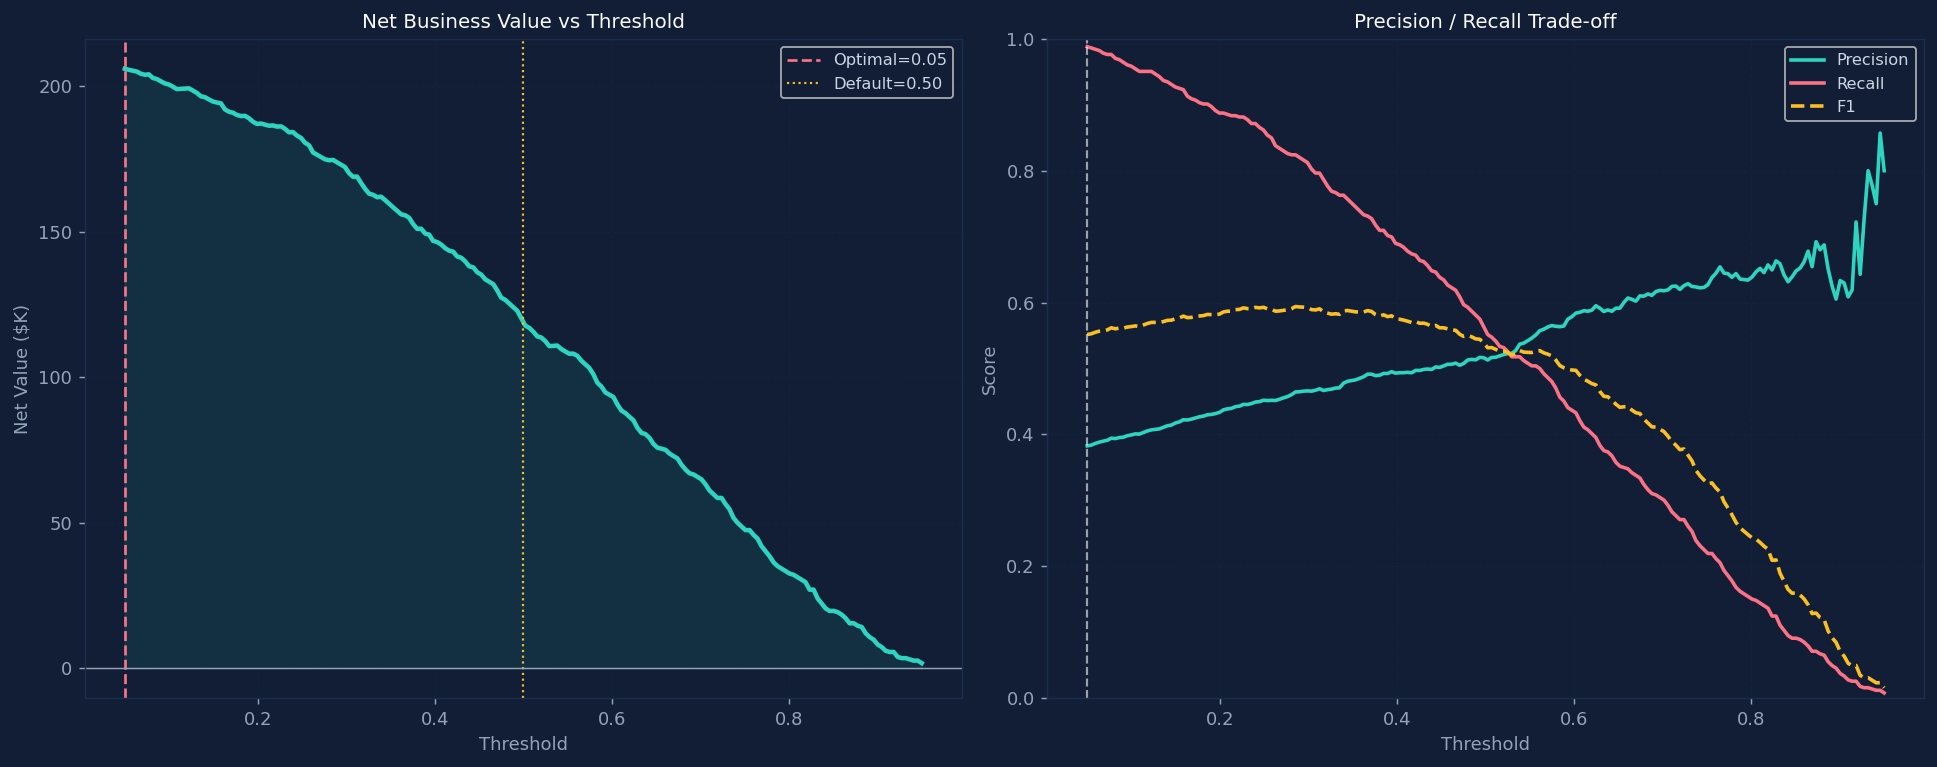

Saved business_value_curve.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(NAVY)
ax = axes[0]; ax.set_facecolor(NAVY)
ax.plot(sweep_df['threshold'], sweep_df['net_value']/1000, color=TEAL, lw=2.5)
ax.fill_between(sweep_df['threshold'], sweep_df['net_value']/1000, 0,
                where=sweep_df['net_value']>0, alpha=0.10, color=TEAL)
ax.axvline(opt_t, color=ROSE, lw=1.5, linestyle='--', label=f'Optimal={opt_t:.2f}')
ax.axvline(0.50, color=AMBER, lw=1.2, linestyle=':', label='Default=0.50')
ax.axhline(0, color=SLATE, lw=0.8)
ax.set_xlabel('Threshold'); ax.set_ylabel('Net Value ($K)')
ax.set_title('Net Business Value vs Threshold', color='#f8fafc', fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax2 = axes[1]; ax2.set_facecolor(NAVY)
ax2.plot(sweep_df['threshold'], sweep_df['precision'], color=TEAL, lw=2, label='Precision')
ax2.plot(sweep_df['threshold'], sweep_df['recall'], color=ROSE, lw=2, label='Recall')
ax2.plot(sweep_df['threshold'], sweep_df['f1'], color=AMBER, lw=2, linestyle='--', label='F1')
ax2.axvline(opt_t, color='#f8fafc', lw=1.2, linestyle='--', alpha=0.6)
ax2.set_xlabel('Threshold'); ax2.set_ylabel('Score')
ax2.set_title('Precision / Recall Trade-off', color='#f8fafc', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(alpha=0.3); ax2.set_ylim(0,1)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/business_value_curve.png', bbox_inches='tight', dpi=130, facecolor=NAVY)
plt.show()
print('Saved business_value_curve.png')

In [6]:
churners_test = test_df[(test_df['churned']==1) & (test_df['churn_proba']>=opt_t)].copy()
seg_impact = churners_test.groupby('segment_label').agg(
    n_targeted=('customer_id','count'),
    monthly_rev_at_risk=('monthly_charges','sum'),
    avg_monthly_rev=('monthly_charges','mean'),
    avg_churn_proba=('churn_proba','mean'),
).reset_index()
seg_impact['expected_saves']  = (seg_impact['n_targeted'] * params.retention_success_rate).round(0)
seg_impact['revenue_saved']   = (seg_impact['expected_saves'] * seg_impact['avg_monthly_rev'] * params.avg_customer_lifetime_mo).round(0)
seg_impact['campaign_cost']   = (seg_impact['n_targeted'] * params.retention_offer_cost).round(0)
seg_impact['net_value']       = (seg_impact['revenue_saved'] - seg_impact['campaign_cost']).round(0)
seg_impact['roi_pct']         = (seg_impact['net_value'] / seg_impact['campaign_cost'] * 100).round(0)
print(seg_impact[['segment_label','n_targeted','expected_saves','revenue_saved','net_value','roi_pct']].to_string(index=False))

                 segment_label  n_targeted  expected_saves  revenue_saved  net_value  roi_pct
🌙 Quietly Disengaging Veterans         207            62.0       142948.0   139843.0   4504.0
    💸 Price-Sensitive Shoppers         223            67.0        74972.0    71627.0   2141.0
   😤 Frustrated Early Adopters          70            21.0        38405.0    37355.0   3558.0


In [7]:
scorecard    = full_scorecard(y_true, y_proba, threshold=opt_t, model_name='LightGBM')
rev_summary  = revenue_at_risk_summary(
    test_df, churn_proba_col='churn_proba',
    monthly_charges_col='monthly_charges',
    threshold=opt_t, params=params
)
action_table = build_action_table(
    df_meta       = test_df[['customer_id','monthly_charges','segment_label']].copy(),
    y_proba       = y_proba,
    uplift_scores = uplift_scores,
    threshold     = opt_t,
    params        = params,
)
print(f'Action table: {len(action_table):,} rows')
action_table.head()

Action table: 1,400 rows


,priority_rank,customer_id,monthly_charges,churn_probability,uplift_score,segment_label,recommended_action,expected_net_value
0,1,CUST54481,116.86,0.3694,0.0620,🌙 Quietly Disengaging Veterans,Offer: Loyalty plan + personal outreach,161.12
1,2,CUST51868,109.57,0.4636,0.0618,🌙 Quietly Disengaging Veterans,Offer: Loyalty plan + personal outreach,202.20
2,3,CUST56555,115.09,0.5129,0.0558,😤 Frustrated Early Adopters,Offer: Free tech support tier upgrade,223.71
3,4,CUST50935,117.81,0.7693,0.0482,🌙 Quietly Disengaging Veterans,Offer: Loyalty plan + personal outreach,335.54
4,5,CUST53707,79.24,0.5920,0.0467,😤 Frustrated Early Adopters,Offer: Free tech support tier upgrade,258.21


In [8]:
def safe(val):
    import numpy as np
    if isinstance(val, (np.integer,)): return int(val)
    if isinstance(val, (np.floating,)): return float(round(val,4))
    if isinstance(val, (np.bool_,)): return bool(val)
    return val

deck_data = {
    'metadata': {'model':'LightGBM v1','test_set_rows':len(test_df)},
    'slide_1_problem': {
        'churn_rate_pct'          : safe(y_true.mean()*100),
        'customers_at_risk'       : safe(rev_summary['n_at_risk']),
        'monthly_revenue_at_risk' : safe(rev_summary['monthly_revenue_at_risk']),
        'annual_revenue_at_risk'  : safe(rev_summary['annual_revenue_at_risk']),
    },
    'slide_5_measurement': {
        'model_auc_roc'       : safe(scorecard['auc_roc'].iloc[0]),
        'model_auc_pr'        : safe(scorecard['auc_pr'].iloc[0]),
        'optimal_threshold'   : safe(opt_t),
        'campaign_net_value'  : safe(opt_row['net_value']),
        'campaign_roi_pct'    : safe(opt_row['roi_pct']),
        'expected_saves'      : safe(rev_summary['expected_saves']),
    },
    'business_params': {
        'avg_monthly_revenue'     : safe(params.avg_monthly_revenue),
        'customer_lifetime_value' : safe(params.customer_lifetime_value),
        'retention_offer_cost'    : params.retention_offer_cost,
        'retention_success_rate'  : params.retention_success_rate,
    },
}

out_path = f'{REPORT_DIR}/cmo_deck_data.json'
with open(out_path, 'w') as f:
    json.dump(deck_data, f, indent=2, default=safe)
print(f'Saved {out_path}')

Saved ../outputs/reports/cmo_deck_data.json


In [9]:
joblib.dump(sweep_df,     f'{MODEL_DIR}/threshold_sweep_v1.pkl')
joblib.dump(action_table, f'{MODEL_DIR}/action_table_v1.pkl')
print('Saved threshold_sweep_v1.pkl')
print('Saved action_table_v1.pkl')
print('\n' + '━'*50)
print('✓ Notebook 05 complete.')
print('  Launch: streamlit run app/streamlit_app.py')
print('━'*50)

Saved threshold_sweep_v1.pkl
Saved action_table_v1.pkl

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ Notebook 05 complete.
  Launch: streamlit run app/streamlit_app.py
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
